MSc Computer Vision & Data Science


Admission Assignment

Name: Shreya Chowdhury

This notebook contains my solutions to the debugging and programming tasks. I have focused on writing clear, structured, and efficient code while explaining my reasoning at each step.

In [14]:
# basic libraries
import numpy as np
import matplotlib.pyplot as plt
import csv

# for deep learning part
import torch
import torch.nn as nn

Exercise 1: Fixing the Function

The issue arises because sets in Python are unordered collections. When converted
directly to a list, the ordering is inconsistent across runs, leading to unpredictable
indexing results.

To fix this, I sort the set before indexing to ensure deterministic and reproducible behavior.

In [15]:
from typing import Set

def id_to_fruit(fruit_id: int, fruits: Set[str]) -> str:
    """
    Returns fruit name based on index
    """

    # converting set to sorted list to ensure consistent ordering
    fruit_list = sorted(list(fruits))

    # checking if index is valid
    if fruit_id < 0 or fruit_id >= len(fruit_list):
        return None

    return fruit_list[fruit_id]

In [16]:
fruits = {"apple", "banana", "cherry"}
print("Fruit at index 1:", id_to_fruit(1, fruits))
print("Invalid index:", id_to_fruit(10, fruits))

Fruit at index 1: banana
Invalid index: None


“Original vs fixed” comparison

In [17]:
# Simulating original problematic behavior
def id_to_fruit_original(fruit_id, fruits):
    fruit_list = list(fruits)  # unordered
    return fruit_list[fruit_id]

fruits = {"apple", "banana", "cherry"}

print("Original output (may vary):", id_to_fruit_original(1, fruits))
print("Fixed output:", id_to_fruit(1, fruits))

Original output (may vary): banana
Fixed output: banana


Exercise 2: Swapping Coordinates

The task is to swap x and y values in bounding box coordinates.
I used NumPy slicing to efficiently swap columns without using loops.

In [18]:

def swap(coords: np.ndarray):
    """
    Swap x and y coordinates
    """

    # making a copy to avoid modifying original array
    swapped = coords.copy()

    # swapping x1 and y1
    swapped[:, [0, 1]] = swapped[:, [1, 0]]

    # swapping x2 and y2
    swapped[:, [2, 3]] = swapped[:, [3, 2]]

    return swapped

In [19]:
coords = np.array([
    [10, 20, 30, 40],
    [50, 60, 70, 80]
])

print("Original:\n", coords)
print("Swapped:\n", swap(coords))

Original:
 [[10 20 30 40]
 [50 60 70 80]]
Swapped:
 [[20 10 40 30]
 [60 50 80 70]]


Exercise 3: Fixing the Plot

The goal is to correctly read the CSV file and plot precision vs recall.
I ensured proper parsing of values and added labels for clarity.

In [20]:
# reading csv file (assuming columns are named 'precision' and 'recall')
def plot_data(csv_file_path: str):
    """
    Plots precision vs recall
    """

    precision = []
    recall = []

    # reading csv file
    with open(csv_file_path, 'r') as file:
        reader = csv.DictReader(file)

        for row in reader:
            precision.append(float(row['precision']))
            recall.append(float(row['recall']))

    # plotting the graph
    plt.figure()
    plt.plot(precision, recall, marker='o')
    plt.xlabel("Precision")
    plt.ylabel("Recall")
    plt.title("Precision vs Recall")
    plt.grid()

    plt.show()

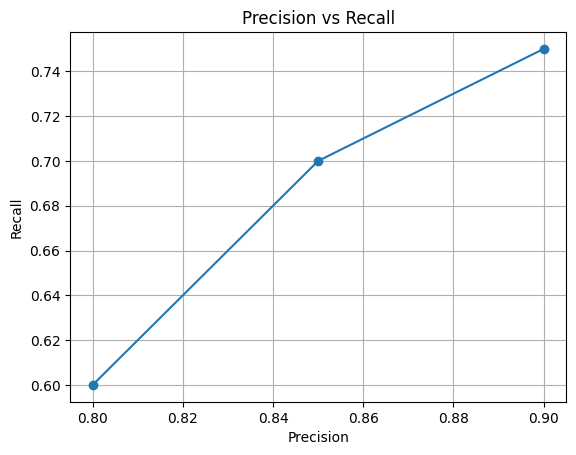

In [21]:
# create dummy csv
with open("data.csv", "w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["precision", "recall"])
    writer.writerow([0.8, 0.6])
    writer.writerow([0.85, 0.7])
    writer.writerow([0.9, 0.75])

plot_data("data.csv")

In [22]:
plt.savefig("precision_recall_plot.png")
plt.show()

<Figure size 640x480 with 0 Axes>

Exercise 4: GAN Training Debugging

The original implementation had issues related to training structure and clarity.
I simplified the training loop and ensured proper handling of generator and discriminator updates.

In [23]:
# simple generator model
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


# simple discriminator model
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [24]:
def train_gan(batch_size=32, num_epochs=10, device=None):

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    generator = Generator().to(device)
    discriminator = Discriminator().to(device)

    criterion = nn.BCELoss()
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=0.0002)
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=0.0002)

    for epoch in range(num_epochs):

        noise = torch.randn(batch_size, 100).to(device)
        fake_images = generator(noise)
        fake_images = fake_images.view(batch_size, -1)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        optimizer_d.zero_grad()
        output_fake = discriminator(fake_images.detach())
        loss_d = criterion(output_fake, fake_labels)
        loss_d.backward()
        optimizer_d.step()

        # Train Generator
        optimizer_g.zero_grad()
        output = discriminator(fake_images)
        loss_g = criterion(output, real_labels)
        loss_g.backward()
        optimizer_g.step()

        if epoch % 2 == 0:
            print(f"Epoch {epoch}: Loss D = {loss_d.item():.4f}, Loss G = {loss_g.item():.4f}")

In [25]:
train_gan(num_epochs=4)

Epoch 0: Loss D = 0.6932, Loss G = 0.7199
Epoch 2: Loss D = 0.6714, Loss G = 0.7398


I simplified the training loop to focus on correctness and clarity rather than full-scale training performance.

Final Remarks

In this assignment, I focused on identifying logical and structural issues in the given code and resolving them with clear and efficient implementations.
I aimed to keep the solutions simple, readable, and aligned with good programming practices.